# **BANK ATTRITION ANALYSIS**

---


### DATA LOADING AND PREPROCESSING

In [69]:
import pandas as pd
df = pd.read_csv("https://gitlab.crio.do/me_notebook/me_jupyter_bankattritionanalysis/-/raw/master/bank_dataset_v3.csv", header = 0, skiprows = [1])

In [70]:
df.head()

,rownumber,customerid,first_name,state,gender,age,tenure,creditscore,balance,hascrcard,...,salary,exited,complain,numcomplain,satisfaction_score,point_earned,preferredchannel,region,employment_type,residential_status
0,2,MH00002,Rohan,Maharashtra,Male,54,4,600,163508.11,1,...,62000,0,0,0,10,150,Mobile,Western,Salaried,Rent
1,3,KA00003,Ananya,Karnataka,Female,58,1,724,138773.12,1,...,97000,0,0,0,5,100,Mobile,Southern,Salaried,Own
2,4,MH00004,Nandini,Maharashtra,Female,39,2,695,136048.53,1,...,157000,0,0,0,10,150,Email,Western,Self-Employed,Rent
3,5,WB00005,Charvi,West Bengal,Female,25,3,675,27798.19,0,...,146000,0,0,0,6,110,Mobile,Eastern,Salaried,Living with family
4,6,KA00006,Ritik,Karnataka,Male,48,3,600,181554.57,1,...,102000,0,0,0,8,130,Mobile,Southern,Business Owner,Rent


In [71]:
df.columns

Index(['rownumber', 'customerid', 'first_name', 'state', 'gender', 'age',
       'tenure', 'creditscore', 'balance', 'hascrcard', 'card_type', 'hasloan',
       'hasfd', 'numofproducts', 'isactivemember', 'salary', 'exited',
       'complain', 'numcomplain', 'satisfaction_score', 'point_earned',
       'preferredchannel', 'region', 'employment_type', 'residential_status'],
      dtype='object')

In [72]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['rownumber', 'customerid', 'first_name', 'state', 'gender', 'age',
       'tenure', 'creditscore', 'balance', 'hascrcard', 'card_type', 'hasloan',
       'hasfd', 'numofproducts', 'isactivemember', 'salary', 'exited',
       'complain', 'numcomplain', 'satisfaction_score', 'point_earned',
       'preferredchannel', 'region', 'employment_type', 'residential_status'],
      dtype='object')

### HANDLING MISSING VALUES

In [73]:
df.isnull().sum()

,0
rownumber,0
customerid,0
first_name,0
state,0
gender,0
age,0
tenure,0
creditscore,0
balance,0
hascrcard,0


In [74]:
df.fillna({'salary' : df['salary'].median()}, inplace = True)
df.fillna({'balance' : 0}, inplace = True)
df.fillna({'satisfaction_score' : df['satisfaction_score'].median()}, inplace = True)
df.dropna(subset = ['gender'], inplace = True)
df.fillna({'card_type' : df['card_type'].mode()[0]}, inplace = True)


In [75]:
df.isnull().sum()

,0
rownumber,0
customerid,0
first_name,0
state,0
gender,0
age,0
tenure,0
creditscore,0
balance,0
hascrcard,0


In [76]:
df['card_type'] = df['card_type'].str.upper().str.strip()
df['card_type'].unique()

array(['GOLD', 'PLATINUM', 'NOT APPLICABLE', 'SILVER'], dtype=object)

### EXPLORE NUMERIC COLUMNS

In [77]:
numeric_columns = df.select_dtypes(include = ['number']).columns.tolist()
numeric_columns

['rownumber',
 'age',
 'tenure',
 'creditscore',
 'balance',
 'hascrcard',
 'hasloan',
 'hasfd',
 'numofproducts',
 'isactivemember',
 'salary',
 'exited',
 'complain',
 'numcomplain',
 'satisfaction_score',
 'point_earned']

In [78]:
unique_counts = {col : df[col].nunique() for col in numeric_columns}
unique_counts

{'rownumber': 14981,
 'age': 73,
 'tenure': 34,
 'creditscore': 483,
 'balance': 12663,
 'hascrcard': 2,
 'hasloan': 2,
 'hasfd': 2,
 'numofproducts': 4,
 'isactivemember': 2,
 'salary': 228,
 'exited': 2,
 'complain': 2,
 'numcomplain': 50,
 'satisfaction_score': 12,
 'point_earned': 110}

### OUTLIER DETECTION AND TREATMENT

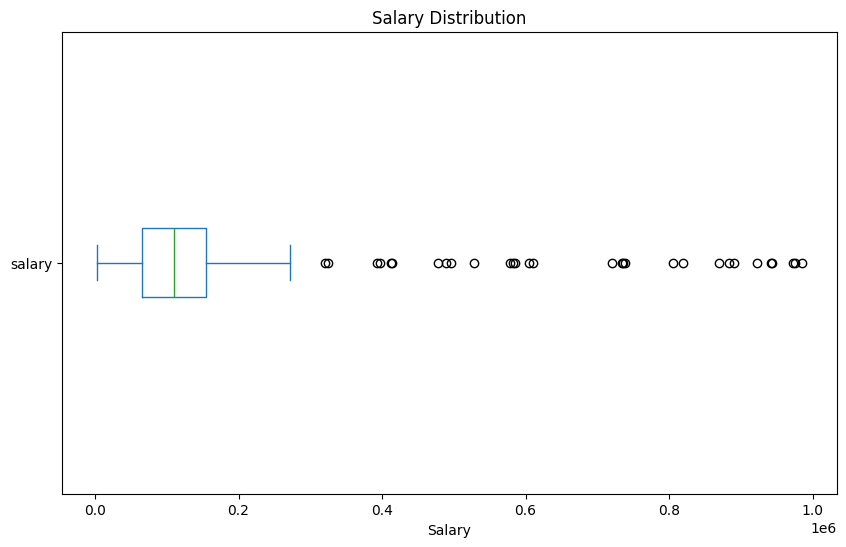

In [79]:
import matplotlib.pyplot as plt
import os

# Create the directory if it does not exist
os.makedirs('outputs/charts/', exist_ok=True)

plt.figure(figsize = (10, 6))
df['salary'].plot(kind = 'box', vert = False)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.savefig('outputs/charts/salary_boxplot.png')
plt.show()

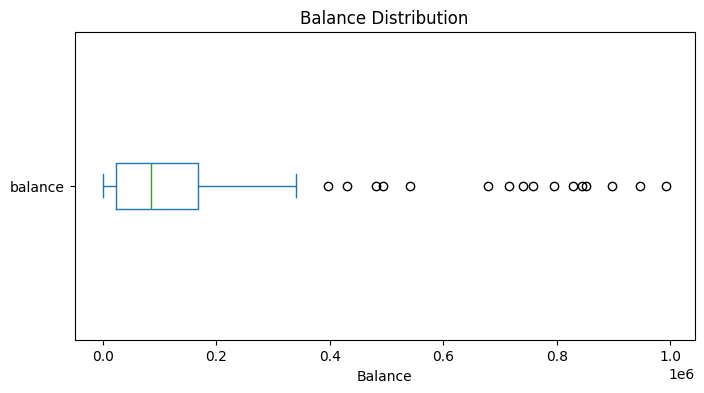

In [80]:
plt.figure(figsize=(8,4))
df['balance'].plot(kind = 'box', vert = False)
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.savefig('outputs/charts/balance_distribution_boxplot.png')
plt.show()

In [81]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

salary_outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]
#Outlier Customers based on salary
salary_outliers['salary']
outlier_count = ((df["salary"] < lower_bound) | (df["salary"] > upper_bound)).sum()
print("Count of Outlier Customers Based on Salary:", outlier_count)

Count of Outlier Customers Based on Salary: 30


In [82]:
import numpy as np
df['salary'] = np.where(df['salary'] > upper_bound, upper_bound, df['salary'])

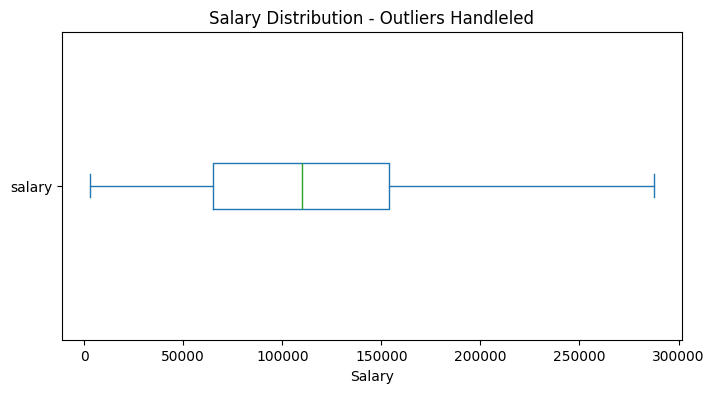

In [83]:
plt.figure(figsize=(8,4))
df['salary'].plot(kind = 'box', vert = False)
plt.title('Salary Distribution - Outliers Handleled')
plt.xlabel('Salary')
plt.savefig('outputs/charts/salary_distribution_boxplot.png')
plt.show()

### EXPLORATORY DATA ANALYSIS (EDA)

In [84]:
#Basic Summary Statistics
mean_salary = round(df['salary'].mean())
median_salary = round(df['salary'].median())

mean_balance = round(df['balance'].mean())
median_balance = round(df['balance'].median())

mean_credit_score = round(df['creditscore'].mean())
median_credit_score = round(df['creditscore'].median())

print(f"mean salary: {mean_salary}, median salary: {median_salary}")
print(f"mean balance: {mean_balance}, median balance: {median_balance}")
print(f"mean credit score: {mean_credit_score}, median credit score: {median_credit_score}")

mean salary: 109794, median salary: 110000
mean balance: 97706, median balance: 84379
mean credit score: 669, median credit score: 684


In [85]:
#Understanding Categorical Variables
gender_counts = df['gender'].value_counts()
card_type_counts = df['card_type'].value_counts()
loan_status_counts = df['hasloan'].value_counts()
fd_status_counts = df['hasfd'].value_counts()
print("Gender Distribution :\n", gender_counts)
print("\nCard Type Distribution :\n", card_type_counts)
print("\nLoan Status Distribution :\n", loan_status_counts)
print("\nFD Status Distribution :\n", fd_status_counts)

Gender Distribution :
 gender
Male      8987
Female    5994
Name: count, dtype: int64

Card Type Distribution :
 card_type
SILVER            4306
GOLD              4094
PLATINUM          3353
NOT APPLICABLE    3228
Name: count, dtype: int64

Loan Status Distribution :
 hasloan
0    11539
1     3442
Name: count, dtype: int64

FD Status Distribution :
 hasfd
0    8311
1    6670
Name: count, dtype: int64


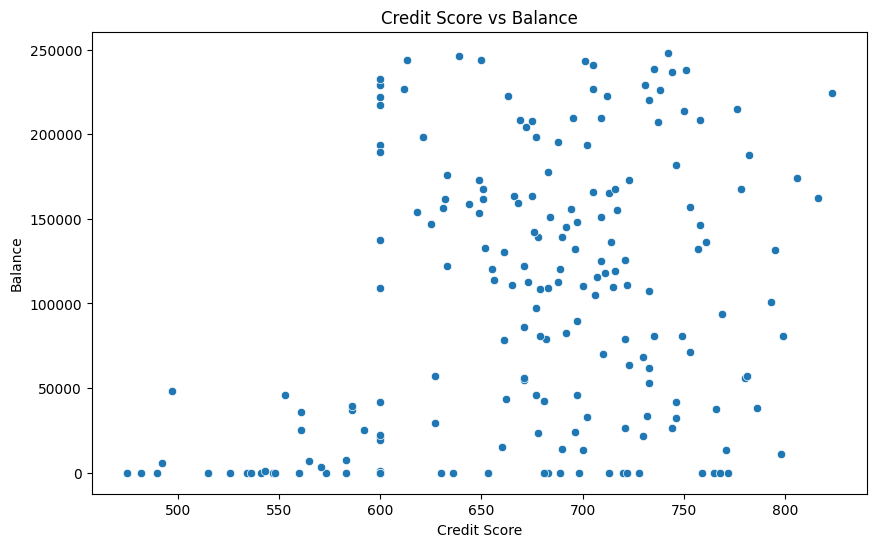

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
df_sample = df.sample(n = 200, random_state= 42)
plt.figure(figsize = (10, 6))
sns.scatterplot(x = df_sample['creditscore'], y = df_sample['balance'])
plt.title('Credit Score vs Balance')
plt.xlabel('Credit Score')
plt.ylabel('Balance')
plt.savefig('outputs/charts/credit_score_vs_balance.png')
plt.show()

### FEATURE EXTRACTION

In [87]:
#Financial Stability Indicator
df['debt_to_income_ratio'] = (df['balance'] + (df['hasloan'] * df['salary'] * 0.3)) / df['salary']
print(df[['first_name', 'debt_to_income_ratio']].tail())

      first_name  debt_to_income_ratio
14976  Vaishnavi              0.300000
14977     Varsha              2.840382
14978     Deepak              0.000000
14979    Anirudh              1.139565
14980     Jhanvi              0.069934


In [88]:
#Calculating Loyalty Score
df['loyalty_score'] = (df['tenure'] * df['satisfaction_score']) / (1 + df['numcomplain'])
df.head()

,rownumber,customerid,first_name,state,gender,age,tenure,creditscore,balance,hascrcard,...,complain,numcomplain,satisfaction_score,point_earned,preferredchannel,region,employment_type,residential_status,debt_to_income_ratio,loyalty_score
0,2,MH00002,Rohan,Maharashtra,Male,54,4,600,163508.11,1,...,0,0,10,150,Mobile,Western,Salaried,Rent,2.937228,40.0
1,3,KA00003,Ananya,Karnataka,Female,58,1,724,138773.12,1,...,0,0,5,100,Mobile,Southern,Salaried,Own,1.730651,5.0
2,4,MH00004,Nandini,Maharashtra,Female,39,2,695,136048.53,1,...,0,0,10,150,Email,Western,Self-Employed,Rent,0.866551,20.0
3,5,WB00005,Charvi,West Bengal,Female,25,3,675,27798.19,0,...,0,0,6,110,Mobile,Eastern,Salaried,Living with family,0.190399,18.0
4,6,KA00006,Ritik,Karnataka,Male,48,3,600,181554.57,1,...,0,0,8,130,Mobile,Southern,Business Owner,Rent,1.779947,24.0


In [89]:
#Analyze Complaints by State
df['state_avg_complaints'] = df.groupby('state')['numcomplain'].transform('mean')
df['above_state_avg_complaints'] = df['numcomplain'] > df['state_avg_complaints']
df['high_complainer'] = df['above_state_avg_complaints'].astype(int)
df.head(10)

,rownumber,customerid,first_name,state,gender,age,tenure,creditscore,balance,hascrcard,...,point_earned,preferredchannel,region,employment_type,residential_status,debt_to_income_ratio,loyalty_score,state_avg_complaints,above_state_avg_complaints,high_complainer
0,2,MH00002,Rohan,Maharashtra,Male,54,4,600,163508.11,1,...,150,Mobile,Western,Salaried,Rent,2.937228,40.0,4.189398,False,0
1,3,KA00003,Ananya,Karnataka,Female,58,1,724,138773.12,1,...,100,Mobile,Southern,Salaried,Own,1.730651,5.0,4.277430,False,0
2,4,MH00004,Nandini,Maharashtra,Female,39,2,695,136048.53,1,...,150,Email,Western,Self-Employed,Rent,0.866551,20.0,4.189398,False,0
3,5,WB00005,Charvi,West Bengal,Female,25,3,675,27798.19,0,...,110,Mobile,Eastern,Salaried,Living with family,0.190399,18.0,4.496331,False,0
4,6,KA00006,Ritik,Karnataka,Male,48,3,600,181554.57,1,...,130,Mobile,Southern,Business Owner,Rent,1.779947,24.0,4.277430,False,0
5,7,WB00007,Yash,West Bengal,Male,44,5,736,238171.06,1,...,130,Mobile,Eastern,Business Owner,Rent,4.630383,40.0,4.496331,False,0
6,8,DL00008,Ishaan,Delhi,Male,26,8,659,220844.13,1,...,120,Mobile,Northern,Salaried,Living with family,4.466870,11.2,4.341834,False,0
7,9,TN00009,Nandini,Tamil Nadu,Female,59,4,660,42700.48,0,...,130,Mobile,Southern,Business Owner,Rent,0.222398,32.0,4.456201,False,0
8,10,TN00010,Meera,Tamil Nadu,Female,58,2,716,52489.95,1,...,140,Phone,Southern,Salaried,Rent,0.330125,18.0,4.456201,False,0
9,11,MH00011,Nikhil,Maharashtra,Male,51,6,664,14429.73,0,...,150,Mobile,Western,Self-Employed,Rent,0.492396,60.0,4.189398,False,0


### UNIVARIATE ANALYSIS

In [90]:
import numpy as np
# Define bins and labels for salary categories
bins = [0, 50000, 100000, 150000, 200000, df['salary'].max()]
labels = ['Low', 'Medium', 'High', 'Very High', 'Above 2 Lakhs']

df['salary_category'] = pd.cut(df['salary'], bins=bins, labels=labels, right=True, include_lowest=True)
# Ensure the Salary Category is ordered for consistent plotting
df['salary_category'] = pd.Categorical(df['salary_category'], categories=labels, ordered=True)

salary_counts = df['salary_category'].value_counts()
salary_counts

,count
salary_category,
High,4170
Medium,4125
Very High,4084
Low,2571
Above 2 Lakhs,31


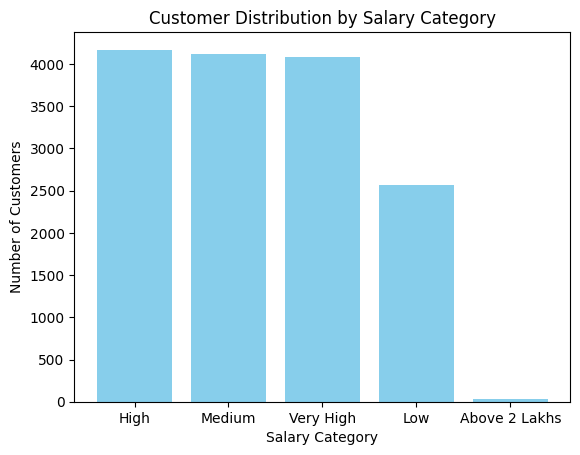

In [91]:
plt.bar(salary_counts.index, salary_counts.values, color = 'skyblue')
plt.xlabel('Salary Category')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Salary Category')
plt.savefig('outputs/charts/customer_distribution_by_salary_category.png')
plt.show()

### BIVARIATE ANALYSIS

In [92]:
tenure_product_analysis = df.groupby("tenure")['numofproducts'].mean()
print("Average Number of Products Based on Customer Tenure:")
tenure_product_analysis

Average Number of Products Based on Customer Tenure:


,numofproducts
tenure,
1,1.427511
2,1.449034
3,1.460390
4,1.484986
5,1.472791
6,1.482245
7,1.385753
8,1.460507
9,1.496195


###MULTIVARIATE ANALYSIS

In [93]:
churn_analysis = df.groupby("exited")[['salary', 'numofproducts']].mean()
churn_analysis

,salary,numofproducts
exited,,
0,115003.610558,1.505976
1,88395.669962,1.267303


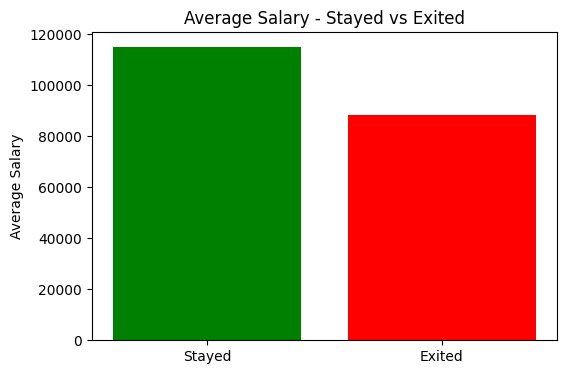

In [94]:
plt.figure(figsize = (6,4))
plt.bar(['Stayed','Exited'], churn_analysis['salary'], color = ['green', 'red'])
plt.title("Average Salary - Stayed vs Exited")
plt.ylabel('Average Salary')
plt.savefig('outputs/charts/average_salary_stayed_vs_exited.png')
plt.show()

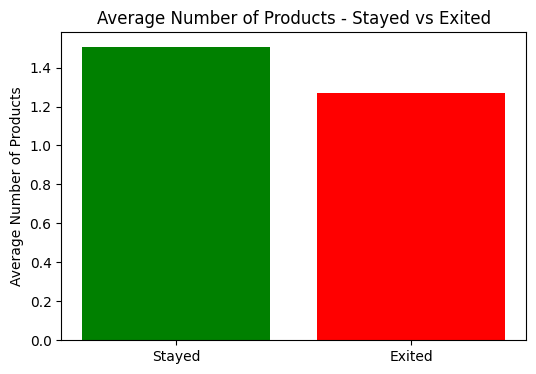

In [95]:
plt.figure(figsize = (6,4))
plt.bar(['Stayed','Exited'], churn_analysis['numofproducts'], color = ['green', 'red'])
plt.title("Average Number of Products - Stayed vs Exited")
plt.ylabel('Average Number of Products')
plt.savefig('outputs/charts/average_num_of_products_stayed_vs_exited.png')
plt.show()


###DEMOGRAPHIC ANALYSIS

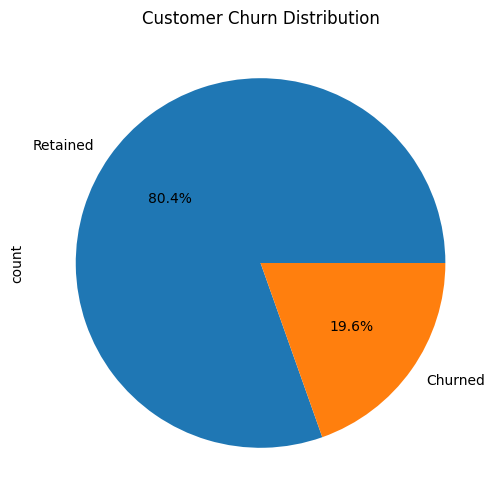

In [96]:
#Visualize Customers by Churn Status
churn_counts = df['exited'].value_counts()
labels = ['Retained', 'Churned']
plt.figure(figsize=(6, 6))
churn_counts.plot(kind = 'pie', labels = labels, autopct = '%1.1f%%')
plt.title("Customer Churn Distribution")
plt.savefig('outputs/charts/customer_churn_distribution.png')
plt.show()

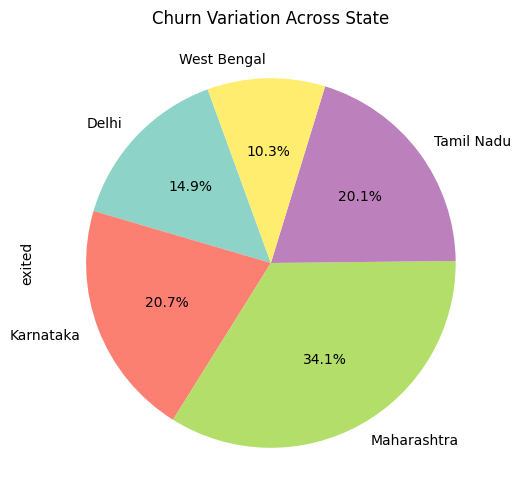

In [97]:
from enum import auto
#Chrun Variation Across State
region_grouped = df.groupby('state')
region_exited = region_grouped['exited']
region_churn_count = region_exited.sum()

plt.figure(figsize= (8,6))
region_churn_count.plot(kind = 'pie', autopct = '%1.1f%%', startangle = 110, cmap = 'Set3')
plt.title('Churn Variation Across State')
plt.savefig('outputs/charts/churn_variation_across_state.png')
plt.show()

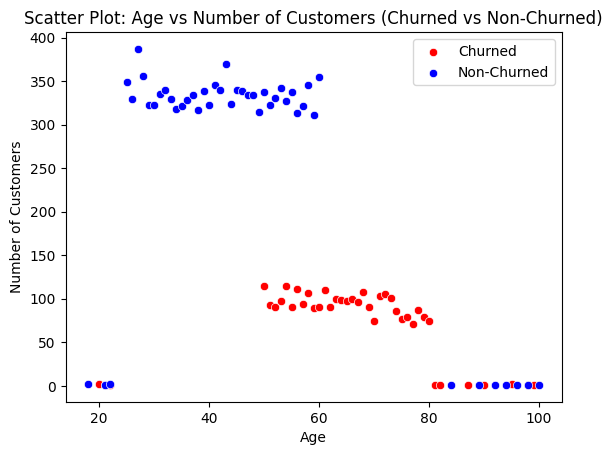

In [98]:
#Age vs Exit Status
churned_count = df[df['exited'] == 1].groupby('age').size()
not_churned_count = df[df['exited'] == 0].groupby('age').size()
sns.scatterplot(x = churned_count.index, y = churned_count.values, color = 'red', label = 'Churned')
sns.scatterplot(x = not_churned_count.index, y = not_churned_count.values, color = 'blue', label = 'Non-Churned')
plt.title("Scatter Plot: Age vs Number of Customers (Churned vs Non-Churned)")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.savefig('outputs/charts/age_vs_number_of_customers.png')
plt.show()

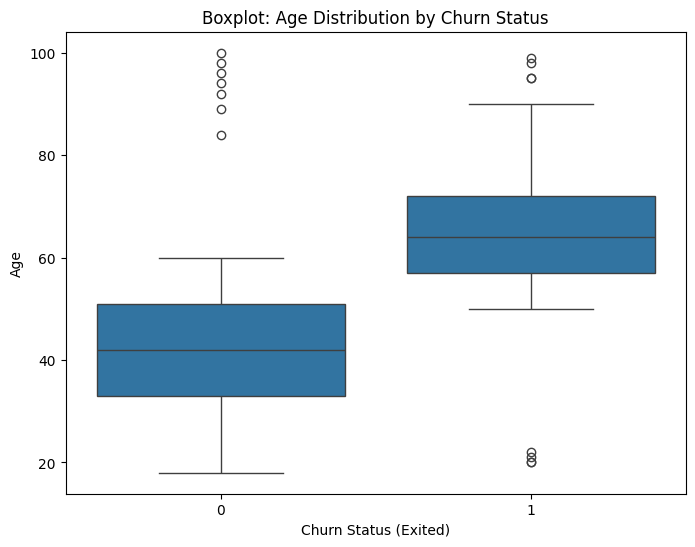

In [99]:
#Age Distribution and Exit Status
plt.figure(figsize = (8,6))
sns.boxplot(x= 'exited', y = 'age', data = df)
plt.title('Boxplot: Age Distribution by Churn Status')
plt.xlabel("Churn Status (Exited)")
plt.ylabel("Age")
plt.savefig('outputs/charts/age_distribution_by_churn_status.png')
plt.show()

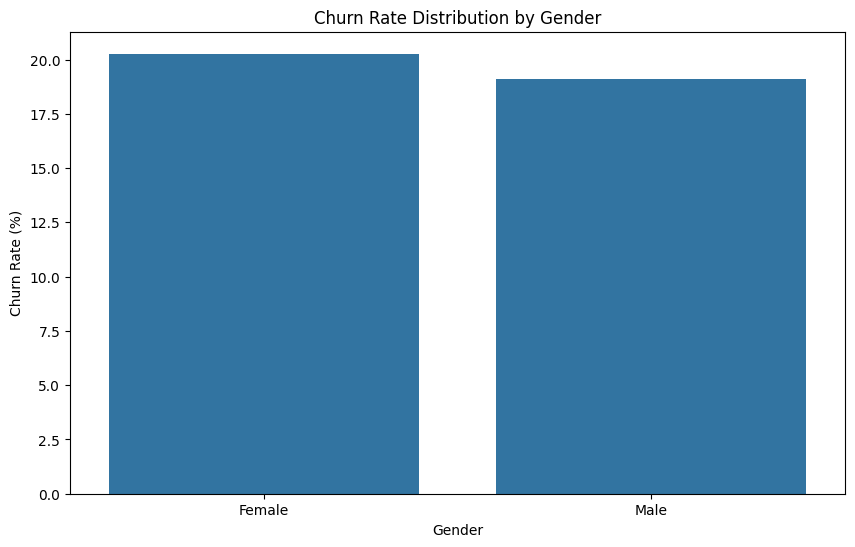

In [100]:
#Gender and Exit Status
churned_customers_df = df[df['exited'] == 1]
total_customers_by_gender = df.groupby('gender')['exited'].count()
churned_customers_by_gender = churned_customers_df.groupby('gender')['exited'].count()
churn_rate_by_gender = (churned_customers_by_gender / total_customers_by_gender) * 100
plt.figure(figsize = (10, 6))
sns.barplot(x = churn_rate_by_gender.index, y = churn_rate_by_gender.values)
plt.title('Churn Rate Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.savefig('outputs/charts/churn_rate_distribution_by_gender.png')
plt.show()

<Figure size 1000x600 with 0 Axes>

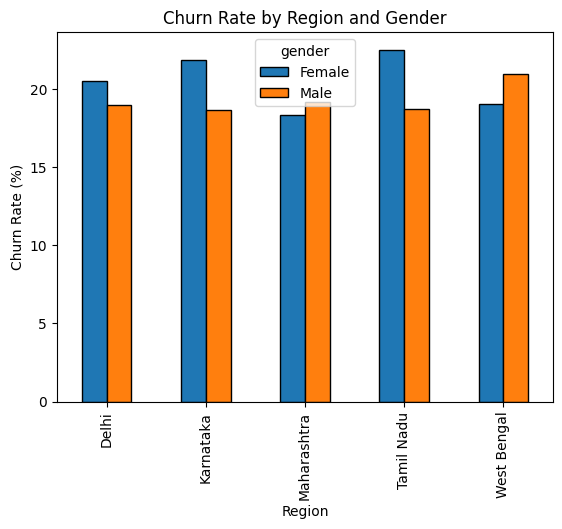

In [101]:
#Churn Rate by Region and Gender
grouped_data = df.groupby(['state', 'gender'])
total_customers = grouped_data['exited'].count()
churned_customers = grouped_data['exited'].sum()
churn_rate = (churned_customers / total_customers) * 100
churn_rate_unstacked = churn_rate.unstack()
plt.figure(figsize = (10, 6))
churn_rate_unstacked.plot(kind = 'bar', edgecolor = 'black')
plt.title("Churn Rate by Region and Gender")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")
plt.savefig('outputs/charts/churn_rate_by_region_and_gender.png')
plt.show()

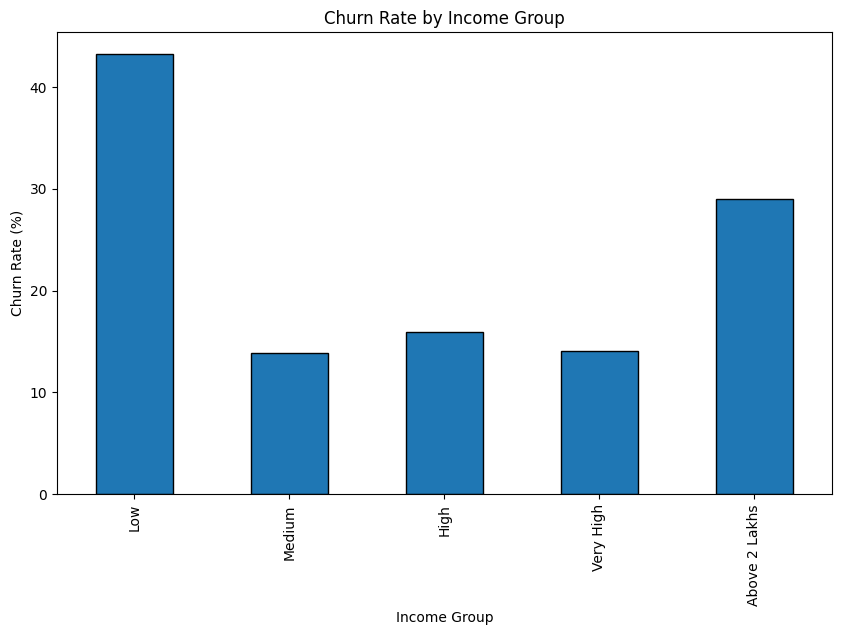

In [102]:
#Relationship Between Income Groups, Salary and Churn Rate
bins = [0, 50000, 100000, 150000, 200000, df['salary'].max()]
labels = ['Low', 'Medium', 'High', 'Very High', 'Above 2 Lakhs']

df['income_group'] = pd.cut(df['salary'], bins = bins, labels = labels, right=True, include_lowest=True)

# Ensure the income_group is ordered for consistent plotting
df['income_group'] = pd.Categorical(df['income_group'], categories=labels, ordered=True)

total_customers_by_income = df.groupby('income_group', observed=True)['exited'].count()
churned_customers_by_income = df.groupby('income_group', observed=True)['exited'].sum()
churn_rate_by_income = (churned_customers_by_income / total_customers_by_income) * 100

plt.figure(figsize = (10, 6))
churn_rate_by_income.plot(kind = 'bar', edgecolor = 'black')
plt.title("Churn Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Churn Rate (%)")
plt.savefig('outputs/charts/churn_rate_by_income_group.png')
plt.show()

In [103]:
age_bins = [18, 30, 45, 60, 100]
age_labels = ['18-30', '31-45', '46-60', '60+']
df['age_group'] = pd.cut(df['age'], bins = age_bins, labels = age_labels, right = False, ordered=True)
df.columns

Index(['rownumber', 'customerid', 'first_name', 'state', 'gender', 'age',
       'tenure', 'creditscore', 'balance', 'hascrcard', 'card_type', 'hasloan',
       'hasfd', 'numofproducts', 'isactivemember', 'salary', 'exited',
       'complain', 'numcomplain', 'satisfaction_score', 'point_earned',
       'preferredchannel', 'region', 'employment_type', 'residential_status',
       'debt_to_income_ratio', 'loyalty_score', 'state_avg_complaints',
       'above_state_avg_complaints', 'high_complainer', 'salary_category',
       'income_group', 'age_group'],
      dtype='object')

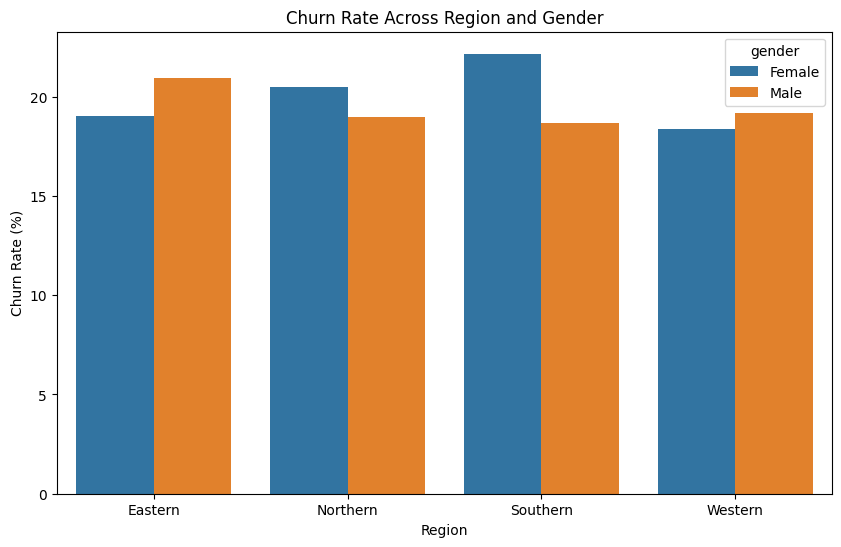

In [104]:
#Churn Rate Across Region and Gender
grouped_data = df.groupby(['region', 'gender'])
total_customers = grouped_data['exited'].count()
churned_customers = grouped_data['exited'].sum()
churn_rate = (churned_customers / total_customers) * 100
churn_rate_by_region_and_gender = churn_rate.reset_index(name = 'churn_rate')

plt.figure(figsize = (10, 6))
sns.barplot(x = 'region', y = 'churn_rate', hue = 'gender', data = churn_rate_by_region_and_gender)
plt.title("Churn Rate Across Region and Gender")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")
plt.savefig('outputs/charts/churn_rate_across_region_and_gender.png')
plt.show()

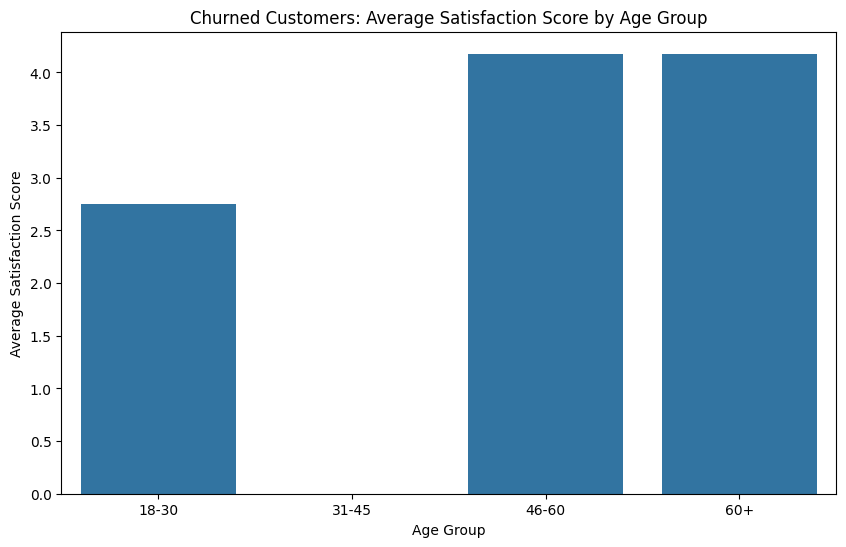

In [105]:
#Average Satisfaction Score for Age Groups
churned_customers = df[df['exited'] == 1]
total_churned_per_age_group = churned_customers.groupby('age_group', observed=True)['satisfaction_score'].count()
avg_satisfaction_churned = churned_customers.groupby('age_group', observed=True)['satisfaction_score'].mean().reset_index(name = 'avg_satisfaction_score')
avg_satisfaction_churned = avg_satisfaction_churned.dropna(subset = 'avg_satisfaction_score')

plt.figure(figsize = (10, 6))
sns.barplot(x = 'age_group', y = 'avg_satisfaction_score', data = avg_satisfaction_churned)
plt.title("Churned Customers: Average Satisfaction Score by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Satisfaction Score")
plt.savefig('outputs/charts/churned_customers_average_satisfaction_score_by_age_group.png')
plt.show()

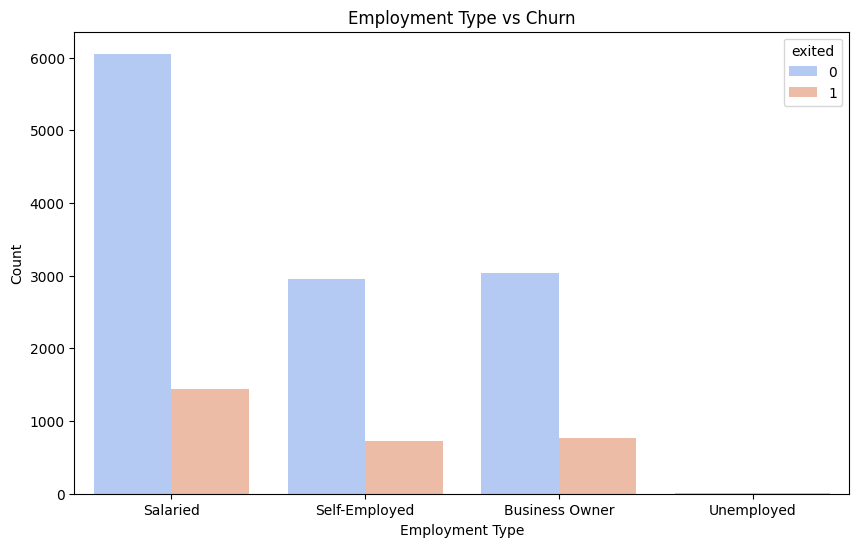

In [106]:
#Count of Customers by Employment type, Highlighting Churned vs Non-Churned Customers
counts = df.groupby(['employment_type', 'exited']).size().reset_index()
plt.figure(figsize = (10, 6))
sns.countplot(x = 'employment_type', hue = 'exited', data = df, palette = 'coolwarm')
plt.title("Employment Type vs Churn")
plt.xlabel("Employment Type")
plt.ylabel("Count")
plt.savefig('outputs/charts/employment_type_vs_churn.png')
plt.show()

In [107]:
#Churn Rate by State
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'colab'
grouped_data = df.groupby('state')

total_customers_by_state = grouped_data['exited'].count()
churned_customers_by_state = grouped_data['exited'].sum()
churn_rate_by_state = (churned_customers_by_state / total_customers_by_state) * 100
churn_rate_by_state_df = churn_rate_by_state.reset_index(name="churn_rate")

fig_bar = px.bar(churn_rate_by_state_df, x='state', y='churn_rate', title="Churn Rate by State")
fig_bar.write_html("outputs/charts/churn_rate_by_state.html")

fig_bar.show()

###PRODUCT ANALYSIS

In [108]:
df.columns

Index(['rownumber', 'customerid', 'first_name', 'state', 'gender', 'age',
       'tenure', 'creditscore', 'balance', 'hascrcard', 'card_type', 'hasloan',
       'hasfd', 'numofproducts', 'isactivemember', 'salary', 'exited',
       'complain', 'numcomplain', 'satisfaction_score', 'point_earned',
       'preferredchannel', 'region', 'employment_type', 'residential_status',
       'debt_to_income_ratio', 'loyalty_score', 'state_avg_complaints',
       'above_state_avg_complaints', 'high_complainer', 'salary_category',
       'income_group', 'age_group'],
      dtype='object')

/tmp/ipykernel_41885/1221328212.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




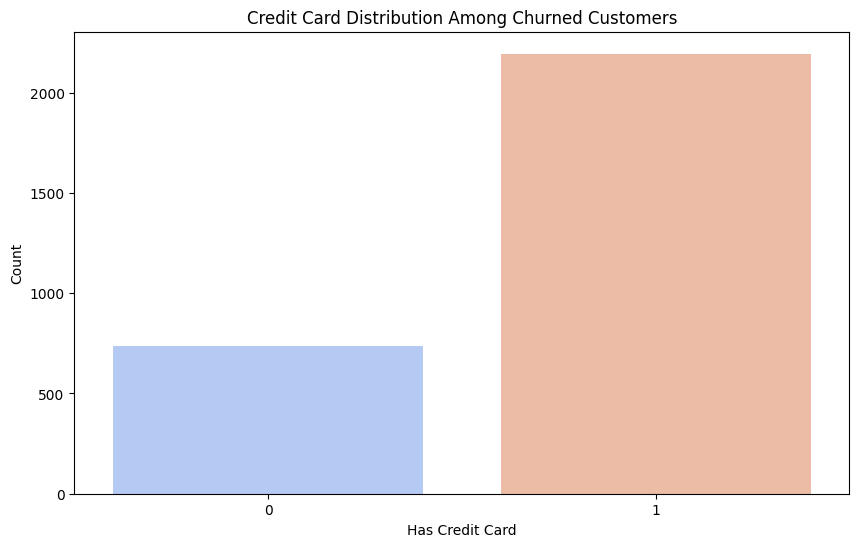

In [109]:
#Credit Card Distribution Among Churned Customers
exited_customers = df[df['exited'] == 1]

plt.figure(figsize = (10, 6))
sns.countplot(x = exited_customers['hascrcard'], palette='coolwarm')
plt.title("Credit Card Distribution Among Churned Customers")
plt.xlabel("Has Credit Card")
plt.ylabel("Count")
plt.savefig('outputs/charts/credit_card_distribution_among_churned_customers.png')
plt.show()


   hascrcard  exited  count
0          0       0   2494
1          0       1    738
2          1       0   9554
3          1       1   2195
14981


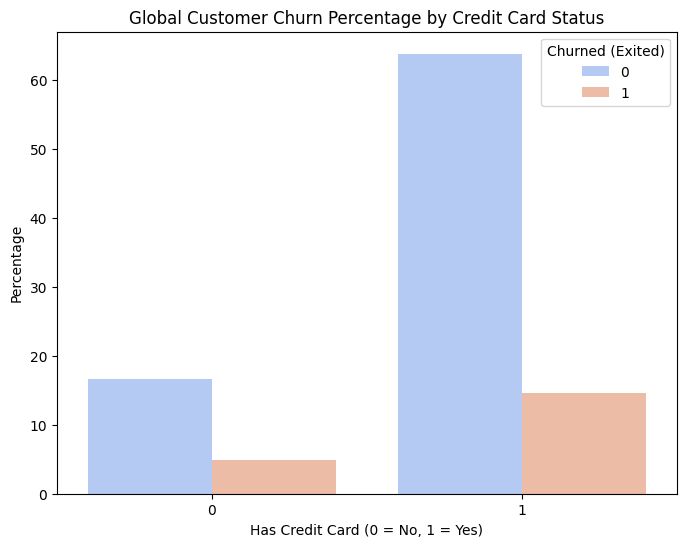

In [110]:
#Global Customer Churn Percentage by Credit Card Status
group_counts = df.groupby(['hascrcard', 'exited']).size().reset_index(name='count')
print(group_counts)
total_customers = group_counts['count'].sum()
print(total_customers)
group_counts['percentage'] = (group_counts['count'] / total_customers) * 100

plt.figure(figsize = (8,6))
sns.barplot(data = group_counts, x = 'hascrcard', y = 'percentage', hue = 'exited', palette = 'coolwarm', errorbar= None)
plt.title("Global Customer Churn Percentage by Credit Card Status")
plt.xlabel("Has Credit Card (0 = No, 1 = Yes)")
plt.ylabel("Percentage")
plt.legend(title = "Churned (Exited)")
plt.tight_layout
plt.savefig('outputs/charts/global_customer_churn_percentage_by_credit_card_status.png')
plt.show()

   hascrcard       card_type  exited  count  percentage
0          0  NOT APPLICABLE       0   2492       16.63
1          0  NOT APPLICABLE       1    736        4.91
2          0          SILVER       0      2        0.01
3          0          SILVER       1      2        0.01
4          1            GOLD       0   3864       25.79
5          1            GOLD       1    230        1.54
6          1        PLATINUM       0   2365       15.79
7          1        PLATINUM       1    988        6.60
8          1          SILVER       0   3325       22.19
9          1          SILVER       1    977        6.52


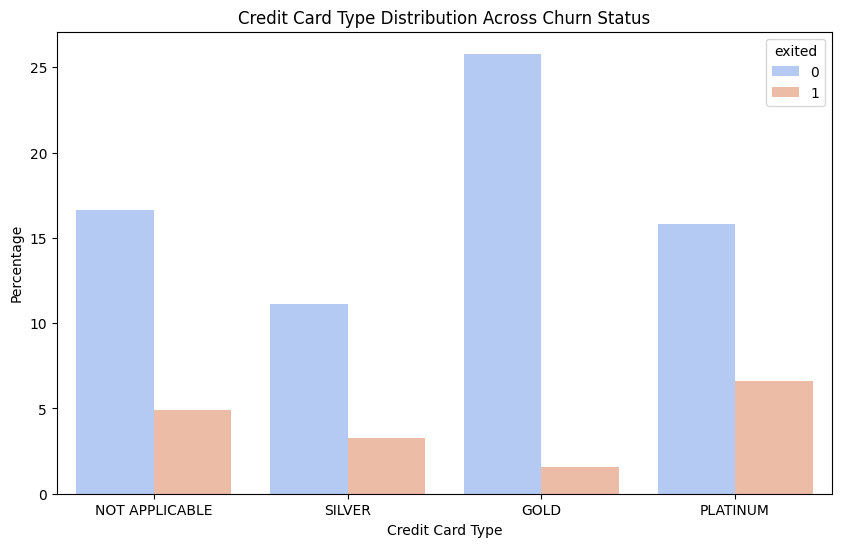

In [111]:
#Credit Card Type Distribution Across Churn Status
card_counts = df.groupby(['hascrcard', 'card_type', 'exited']).size().reset_index(name = 'count')
total_customers = card_counts['count'].sum()
card_counts['percentage'] = ((card_counts['count'] / total_customers) * 100).round(2)
print(card_counts)

plt.figure(figsize = (10, 6))
sns.barplot(data = card_counts, x = 'card_type', y = 'percentage', hue = 'exited', palette = 'coolwarm', errorbar = None)
plt.title("Credit Card Type Distribution Across Churn Status")
plt.xlabel("Credit Card Type")
plt.ylabel("Percentage")
plt.tight_layout
plt.savefig('outputs/charts/credit_card_type_distribution_across_churn_status.png')
plt.show()

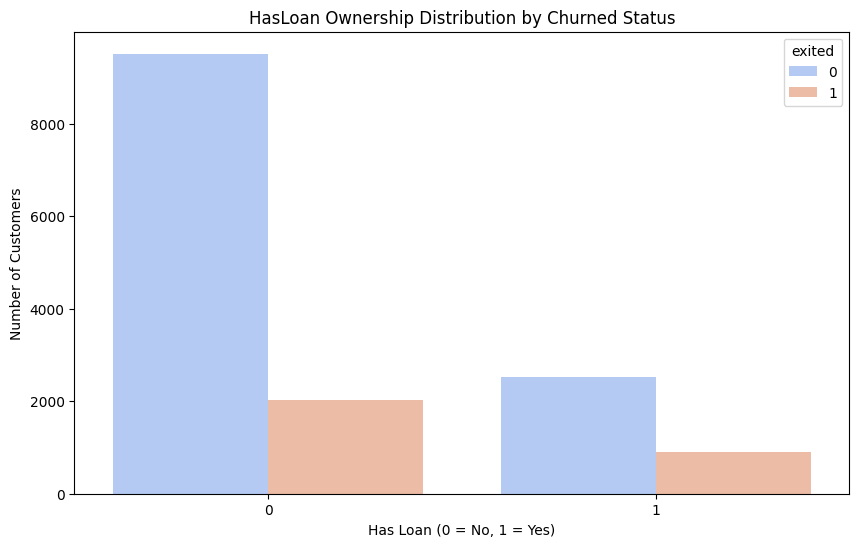

In [112]:
#Loan Ownership vs Churn
plt.figure(figsize = (10, 6))
sns.countplot(x = 'hasloan', hue = 'exited', data = df, palette = 'coolwarm')
plt.title("HasLoan Ownership Distribution by Churned Status")
plt.xlabel("Has Loan (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.savefig('outputs/charts/loan_ownership_distribution_by_churned_status.png')
plt.show()

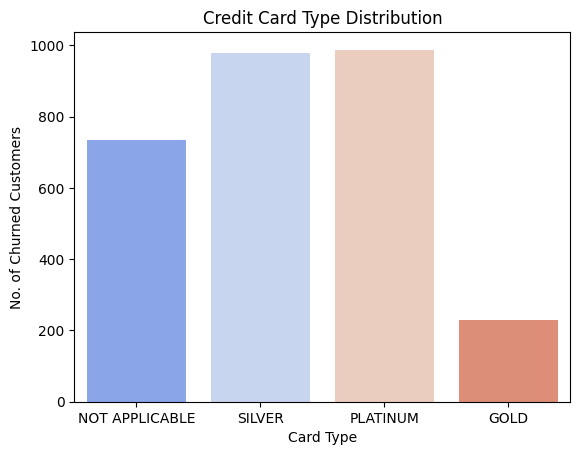

In [113]:
#Number of Products vs Churn
exited_customers = df[df['exited'] == 1]
sns.countplot(x = exited_customers["card_type"], hue = exited_customers["card_type"], palette="coolwarm", legend=False)
plt.title("Credit Card Type Distribution")
plt.xlabel("Card Type")
plt.ylabel("No. of Churned Customers")
plt.savefig('outputs/charts/credit_card_type_distribution.png')
plt.show()

Credit Card Customers: 
exited
0    9554
1    2195
dtype: int64
Loan Count: 
exited
0    2529
1     913
dtype: int64
FD Count: 
exited
0    6061
1     609
dtype: int64


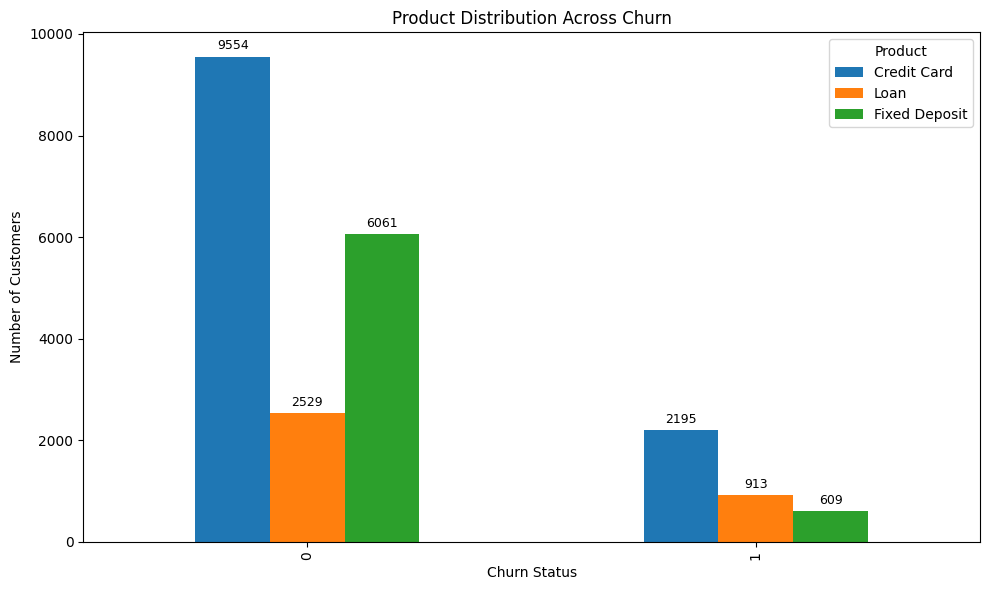

In [114]:
#Product Distribution Across Churn
crcard = df[df['hascrcard'] == 1].groupby('exited').size()
print(f"Credit Card Customers: \n{crcard}")

loan = df[df['hasloan'] == 1].groupby('exited').size()
print(f"Loan Count: \n{loan}")

fd = df[df['hasfd'] == 1].groupby('exited').size()
print(f"FD Count: \n{fd}")

product_dist = pd.DataFrame({'Credit Card': crcard, 'Loan': loan, 'Fixed Deposit': fd})
ax = product_dist.plot(kind = 'bar', figsize = (10, 6))
ax.bar_label(ax.containers[0], fontsize=9, padding=3)
ax.bar_label(ax.containers[1], fontsize=9, padding=3)
ax.bar_label(ax.containers[2], fontsize=9, padding=3)

plt.title("Product Distribution Across Churn")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.legend(title = "Product")
plt.tight_layout()
plt.savefig('outputs/charts/product_distribution_across_churn.png')
plt.show()

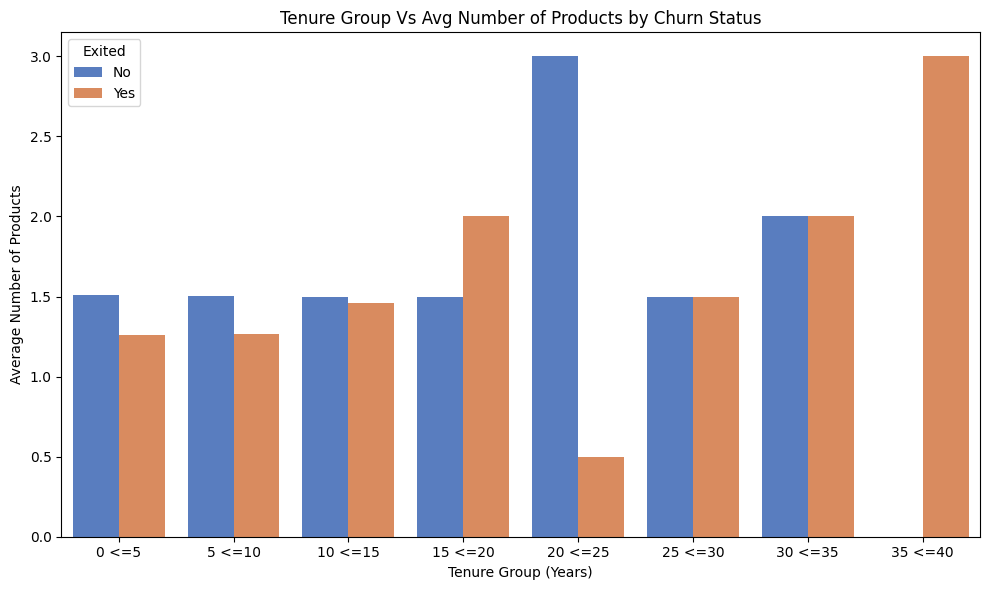

In [115]:
#Average Product Usage by Tenure Groups Across Churn Status

tenure_bins = list(range(0, 41, 5))
tenure_labels = [f'{i} <={i+5}' for i in range(0,36,5)]
df['tenure_group'] = pd.cut(df['tenure'], bins = tenure_bins, labels = tenure_labels, right = False)

plt.figure(figsize = (10, 6))
sns.barplot(data = df, x = 'tenure_group', y = 'numofproducts', hue = 'exited', palette = 'muted', errorbar = None)
plt.title("Tenure Group Vs Avg Number of Products by Churn Status")
plt.xlabel("Tenure Group (Years)")
plt.ylabel("Average Number of Products")
plt.legend(title = "Exited", labels = ['No', 'Yes'])
plt.tight_layout()
plt.savefig('outputs/charts/tenure_group_vs_avg_number_of_products_by_churn_status.png')
plt.show()


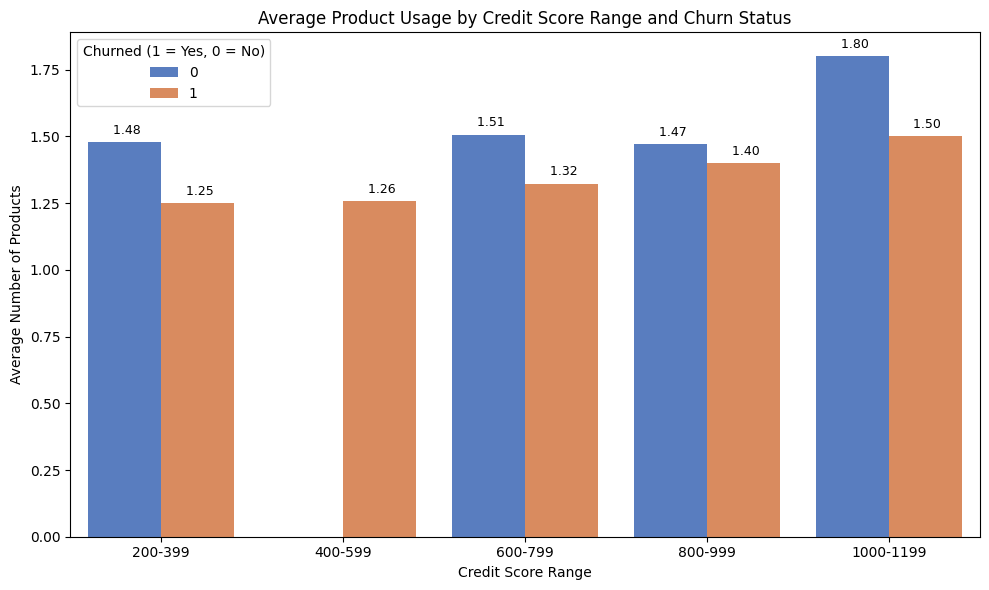

In [116]:
#Average Number of Product Usage by given Credit Scores ranges across Churned Status
credit_bins = [200,400,600,800,1000,1200]
credit_labels = ['200-399','400-599','600-799','800-999','1000-1199']

df['credit_score_range'] = pd.cut(df['creditscore'], bins = credit_bins, labels = credit_labels, right = False, ordered=True)

# Calculate average numofproducts for each group explicitly
avg_products = df.groupby(['credit_score_range', 'exited'], observed=False)['numofproducts'].mean().reset_index()

plt.figure(figsize = (10, 6))
ax = sns.barplot(data = avg_products, x = 'credit_score_range', y = 'numofproducts', hue = 'exited', palette = 'muted')

for p in ax.patches:
  height = p.get_height()
  if pd.notnull(height) and height > 0: # Only label bars that have a height > 0
    ax.text(x = p.get_x() + p.get_width() / 2, y = height + 0.02,
            s = f'{height: .2f}',
            ha = 'center',
            va = 'bottom',
            fontsize = 9
            )

plt.title("Average Product Usage by Credit Score Range and Churn Status")
plt.xlabel("Credit Score Range")
plt.ylabel("Average Number of Products")
plt.legend(title = "Churned (1 = Yes, 0 = No)")
plt.tight_layout()
plt.savefig('outputs/charts/average_product_usage_by_credit_score_range_and_churn_status.png')
plt.show()

###FEEDBACK ANALYSIS

#####ASSUMPTION 1:
    Customers with low satisfaction and low loyalty points are more likely to churn.

In [117]:
df.columns

Index(['rownumber', 'customerid', 'first_name', 'state', 'gender', 'age',
       'tenure', 'creditscore', 'balance', 'hascrcard', 'card_type', 'hasloan',
       'hasfd', 'numofproducts', 'isactivemember', 'salary', 'exited',
       'complain', 'numcomplain', 'satisfaction_score', 'point_earned',
       'preferredchannel', 'region', 'employment_type', 'residential_status',
       'debt_to_income_ratio', 'loyalty_score', 'state_avg_complaints',
       'above_state_avg_complaints', 'high_complainer', 'salary_category',
       'income_group', 'age_group', 'tenure_group', 'credit_score_range'],
      dtype='object')

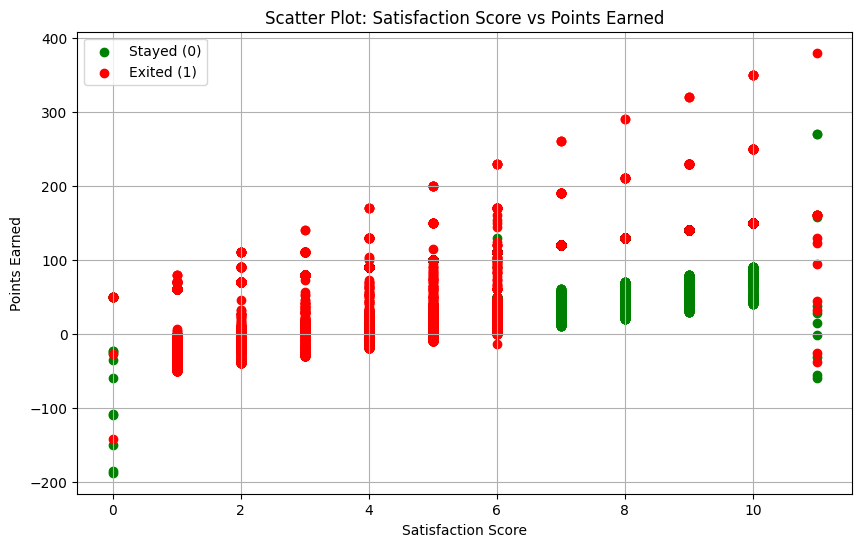

In [118]:
plt.figure(figsize = (10,6))
plt.scatter(df[df['exited'] == 0]['satisfaction_score'], df[df['exited'] == 0]['point_earned'], c = 'green', label = 'Stayed (0)')
plt.scatter(df[df['exited'] == 1]['satisfaction_score'], df[df['exited'] == 1]['point_earned'], c = 'red', label = 'Exited (1)')
plt.title("Scatter Plot: Satisfaction Score vs Points Earned")
plt.xlabel('Satisfaction Score')
plt.ylabel('Points Earned')
plt.grid(True)
plt.legend()
plt.savefig('outputs/charts/scatter_plot_satisfaction_score_vs_points_earned.png')
plt.show()

#####ASSUMPTION 2:
    Customers who churn tend to have lower satisfaction score than those who stay

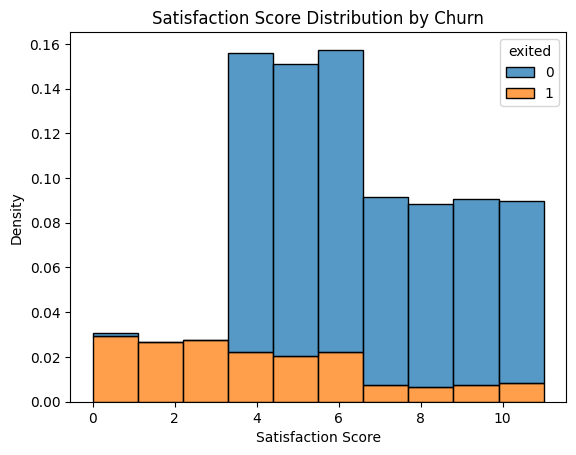

In [119]:
sns.histplot(data = df, x = 'satisfaction_score', hue = df['exited'], bins = 10, multiple = 'stack', stat = 'density')
plt.title("Satisfaction Score Distribution by Churn")
plt.xlabel('Satisfaction Score')
plt.ylabel("Density")
plt.savefig('outputs/charts/satisfaction_score_distribution_by_churn.png')
plt.show()

#####ASSUMPTION 3:
    Among those who complained, a higher proportion ended up churning

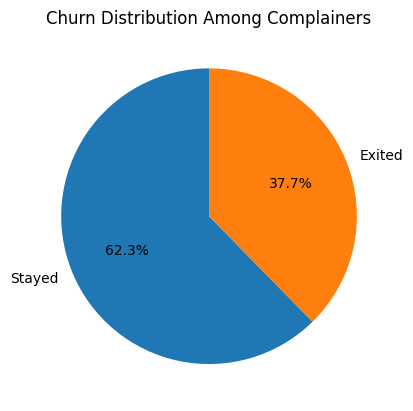

In [120]:
complainers = df[df['complain'] == 1]
churn_distribution = complainers['exited'].value_counts(normalize = True) * 100
plt.pie(churn_distribution, labels = ['Stayed', 'Exited'], autopct = '%1.1f%%', startangle = 90)
plt.title("Churn Distribution Among Complainers")
plt.savefig('outputs/charts/churn_distribution_among_complainers.png')
plt.show()

###FINANCIAL ANALYSIS

#####ASSUMPTION 1:
    Customers with high salary and high balance are less likely to churn

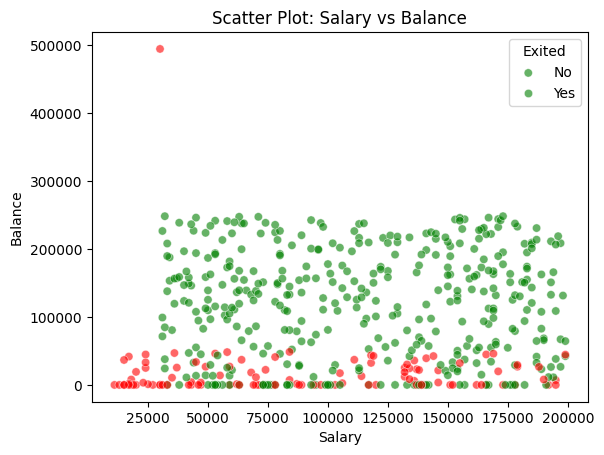

In [121]:
sample_data = df.sample(n = 500, random_state = 42)
sns.scatterplot(data = sample_data, x = 'salary', y = 'balance', hue = 'exited', alpha = 0.6, palette = {0: 'green', 1: 'red'})
plt.title("Scatter Plot: Salary vs Balance")
plt.xlabel("Salary")
plt.ylabel("Balance")
plt.legend(title = "Exited", labels = ['No', 'Yes'])
plt.savefig('outputs/charts/scatter_plot_salary_vs_balance.png')
plt.show()

#####ASSUMPTION 2:
    Customers with more products and lower balance are more likely to churn

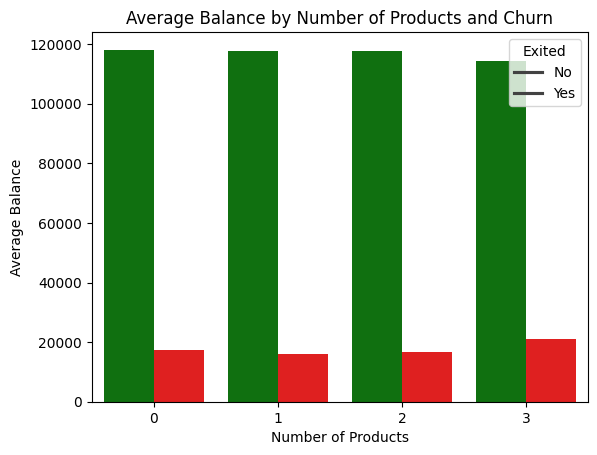

In [122]:
groups = df.groupby(['numofproducts', 'exited'])['balance'].mean().reset_index(name = 'average_balance')
sns.barplot(data = groups, x = 'numofproducts', y = 'average_balance', hue = 'exited', palette = {0: 'green', 1: 'red'})
plt.title("Average Balance by Number of Products and Churn")
plt.xlabel("Number of Products")
plt.ylabel("Average Balance")
plt.legend(title = "Exited", labels = ['No', 'Yes'])
plt.savefig('outputs/charts/average_balance_by_number_of_products_and_churn.png')
plt.show()

#####ASSUMPTION 3:
    Churn Rate differs between FD holders and non-holders

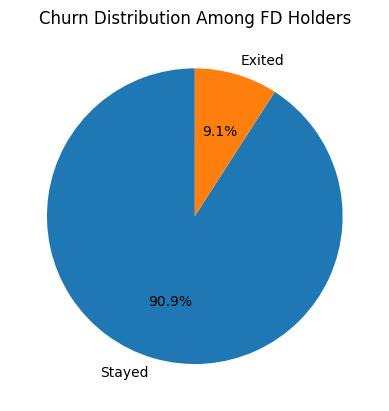

In [123]:
fd_holders = df[df['hasfd'] == 1]
count_fd_hold = fd_holders['exited'].value_counts(normalize = True)
optimized_result = count_fd_hold.round(3)
plt.pie(optimized_result, labels = ['Stayed', 'Exited'], autopct = '%1.1f%%', startangle = 90)
plt.title("Churn Distribution Among FD Holders")
plt.savefig('outputs/charts/churn_distribution_among_fd_holders.png')
plt.show()